#  Build an Interactive Dashboard with Plotly Dash
En este laboratorio, construirás una aplicación Plotly Dash para que los usuarios realicen análisis visual inter-activo sobre los datos de lanzamientos de SpaceX en tiempo real.

Esta aplicación de tablero (dashboard) contiene componentes de entrada como una lista desplegable (dro-pdown list) y un control deslizante de rango (range slider) para interactuar con un gráfico de pastel (pie chart) y un gráfico de dispersión (scatter point chart). Serás guiado para construir esta aplicación de tablero mediante las siguientes tareas:

- **TAREA1**: Agregar un componente de entrada tipo lista desplegable (Drop-down Input Component) para selec-cionar el sitio de lanzamiento
- **TAREA 2:** Agregar una función callback para renderizar el success‑pie‑chart basado en el sitio seleccionado en el menú desplegable
- **TAREA 3:** Agregar un control deslizante de rango (Range Slider) para seleccionar el payload  
- **TAREA 4:** Agregar una función callback para renderizar el gráfico de dispersión success‑payload‑scatter‑chart

**Nota**: Toma capturas de pantalla del Dashboard y guárdalas. Luego sube tu cuaderno (notebook) a GitHub.

La URL de GitHub y las capturas de pantalla serán requeridas más adelante en las diapositivas de la presentación.



In [1]:
# Instalar las librerías necesarias
!pip install packaging

In [2]:
!pip install pandas dash

In [3]:
!pip install dash plotly

In [4]:
# Import required packages
import pandas as pd
import dash
from dash import html
from dash import dcc
from dash.dependencies import Input, Output
import plotly.express as px

In [5]:
# Read the airline data into pandas dataframe
spacex_df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv")
max_payload = spacex_df['Payload Mass (kg)'].max()
min_payload = spacex_df['Payload Mass (kg)'].min()
spacex_df.head()

,Unnamed: 0,Flight Number,Launch Site,class,Payload Mass (kg),Booster Version,Booster Version Category
0,0,1,CCAFS LC-40,0,0.0,F9 v1.0 B0003,v1.0
1,1,2,CCAFS LC-40,0,0.0,F9 v1.0 B0004,v1.0
2,2,3,CCAFS LC-40,0,525.0,F9 v1.0 B0005,v1.0
3,3,4,CCAFS LC-40,0,500.0,F9 v1.0 B0006,v1.0
4,4,5,CCAFS LC-40,0,677.0,F9 v1.0 B0007,v1.0


## Descarga del esqueleto de la aplicación dashboard
[spacex-dash-app.py](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/t4-Vy4iOU19i8y6E3Px_ww/spacex-dash-app.py)
````
# Import required libraries
import pandas as pd
import dash
from dash import html
from dash import dcc
from dash.dependencies import Input, Output
import plotly.express as px

# Read the airline data into pandas dataframe
spacex_df = pd.read_csv("spacex_launch_dash.csv")
max_payload = spacex_df['Payload Mass (kg)'].max()
min_payload = spacex_df['Payload Mass (kg)'].min()

# Create a dash application
app = dash.Dash(__name__)

# Create an app layout
app.layout = html.Div(children=[html.H1('SpaceX Launch Records Dashboard',
                                        style={'textAlign': 'center', 'color': '#503D36',
                                               'font-size': 40}),
                                # TASK 1: Add a dropdown list to enable Launch Site selection
                                # The default select value is for ALL sites
                                # dcc.Dropdown(id='site-dropdown',...)
                                html.Br(),

                                # TASK 2: Add a pie chart to show the total successful launches count for all sites
                                # If a specific launch site was selected, show the Success vs. Failed counts for the site
                                html.Div(dcc.Graph(id='success-pie-chart')),
                                html.Br(),

                                html.P("Payload range (Kg):"),
                                # TASK 3: Add a slider to select payload range
                                #dcc.RangeSlider(id='payload-slider',...)

                                # TASK 4: Add a scatter chart to show the correlation between payload and launch success
                                html.Div(dcc.Graph(id='success-payload-scatter-chart')),
                                ])

# TASK 2:
# Add a callback function for `site-dropdown` as input, `success-pie-chart` as output

# TASK 4:
# Add a callback function for `site-dropdown` and `payload-slider` as inputs, `success-payload-scatter-chart` as output


# Run the app
if __name__ == '__main__':
    app.run()
````
A continuación, llenaremos la aplicación base con los componentes de las funciones *callback*
Si necesitas refrescar tu memoria sobre los componentes de Plotly Dash y las funciones callback* puedes consultar el laboratorio que aprendiste anteriormente: [4.7_Dash_Interactivity.py](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/Module%204/4.7_Dash_Interactivity.py)

### Tarea 1
Agregar un componente de entrada tipo lista desplegable para el sitio de lanzamiento
Tenemos cuatro sitios de lanzamiento diferentes y primero nos gustaría ver cuál de ellos tiene la mayor canti-dad de éxitos. Luego, nos gustaría seleccionar un sitio específico y revisar su tasa de éxito detallada (class = 0 vs. class = 1).
Por lo tanto, necesitaremos un menú desplegable (dropdown menu) que nos permita seleccionar diferentes sitios de lanzamiento.
Encuentra y completa un componente comentado 
```` 
#dcc.Dropdown(id='site-dropdown', ...)
```` 
con los siguientes atributos:
- El atributo **id** con el valor **site-dropdown**
- El atributo **options** es una lista de objetos tipo diccionario (con atributos **label** y **value**). Puedes establecer tanto el label como el value con los nombres de los sitios de lanzamiento en *spacex_df*, y debes incluir la opción predeterminada **All**. Por ejemplo:
````
  options=[{'label': 'All Sites', 'value': 'ALL'},{'label': 'site1', 'value': 'site1'}, ...]
````
- El atributo **value** con el valor predeterminado del menú desplegable debe ser *ALL*, lo que significa que se seleccionan todos los sitios.
- El atributo **placeholder** debe mostrar una descripción de texto sobre esta área de entrada, por ejemplo: Select a Launch Site here.
- El atributo **searchable** debe ser *True* para que podamos ingresar palabras clave y buscar sitios de lanzamiento.

Aquí está un ejemplo de ***dcc.Dropdown***:
```` 
dcc.Dropdown(id='id',
                options=[
                    {'label': 'All Sites', 'value': 'ALL'},
                    {'label': 'site1', 'value': 'site1'},
                ],
                value='ALL',
                placeholder="place holder here",
                searchable=True
                ),
```` 
Si necesitas más ayuda respecto a Dropdown(), refiérete a la sección **Plotly Dash Reference hacia el final de este laboratorio**.
Haz completado el menú dropdown que debe verse como la siguiente pantalla:
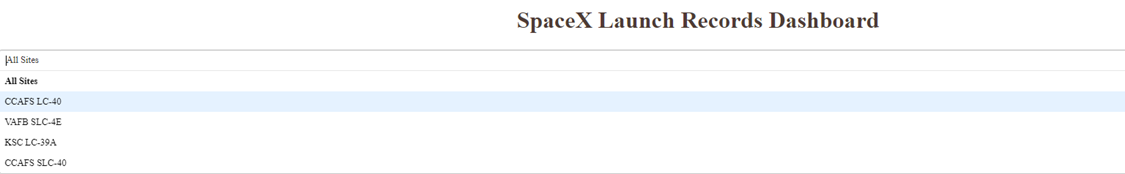


In [6]:
# Create a dash application
app = dash.Dash(__name__)

# Create an app layout
app.layout = html.Div(children=[
    html.H1('SpaceX Launch Records Dashboard',
            style={'textAlign': 'center', 'color': '#503D36', 'font-size': 40}),
# TASK 1: Add a dropdown list to enable Launch Site selection
# The default select value is for ALL sites
    dcc.Dropdown(
        id='site-dropdown',
        options=[
            {'label': 'All Sites', 'value': 'ALL'},
            {'label': 'CCAFS LC-40', 'value': 'CCAFS LC-40'},
            {'label': 'CCAFS SLC-40', 'value': 'CCAFS SLC-40'},
            {'label': 'KSC LC-39A', 'value': 'KSC LC-39A'},
            {'label': 'VAFB SLC-4E', 'value': 'VAFB SLC-4E'}
        ],
        value='ALL',
        placeholder="Select a Launch Site",
        searchable=True
    ),
                                html.Br(),

# TASK 2: Add a pie chart to show the total successful launches count for all sites
# If a specific launch site was selected, show the Success vs. Failed counts for the site
    html.Div(dcc.Graph(id='success-pie-chart')),
    html.Br(),

    html.P("Payload range (Kg):"),
                                
# TASK 3: Add a slider to select payload range
    dcc.RangeSlider(
        id='payload-slider',
        min = 0,
        max = 10000,
        step=1000,
        value = [min_payload, max_payload]
    ),

# TASK 4: Add a scatter chart to show the correlation between payload and launch success
        html.Div(dcc.Graph(id='success-payload-scatter-chart')),
])


### Tarea 2. Añade una función callback para renderizar success-pie-chart basado en el sitio elegido del dropdown 
La idea general de esta función callback es obtener el sitio de lanzamiento seleccionado desde site-dropdown y renderizar un gráfico de pastel que visualice los conteos de lanzamientos exitosos.

Una función callback de Dash es un tipo de función de Python que será llamada automáticamente por Dash cada vez que reciba actualizaciones de un componente de entrada, como un clic o un evento de selección en un menú desplegable.

Si necesitas refrescar tu memoria sobre las fucin¡ones callback de Ploytly Dash, puedes consultar el laborato-rio que aprendiste anteriormente: [4.7_Dash_Interactivity.py](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/Module%204/4.7_Dash_Interactivity.py)
Agreguemos una función callback en *spacex_dash_app.py* que incluya la siguiente lógica de aplicación:

La entrada (Input) debe ser el menú desplegable site-dropdown, es decir:
```` 
Input(component_id='site-dropdown', component_property='value')
```` 
La salida (Output) debe ser el gráfico con id success-pie-chart, es decir:
```` 
Output(component_id='success-pie-chart', component_property='figure')
```` 
Una sentencia If–Else para verificar si se seleccionaron TODOS los sitios o solo un sitio de lanzamiento especí-fico.

Si se seleccionan TODOS los sitios, utilizaremos todas las filas del dataframe spacex_df para renderizar y de-volver un gráfico de pastel que muestre el total de lanzamientos exitosos (es decir, el conteo total de la colum-na class).

Si se selecciona un sitio de lanzamiento específico, primero debes filtrar el dataframe spacex_df para incluir únicamente los datos del sitio seleccionado. Luego, renderizar y devolver un gráfico de pastel que muestre el conteo de éxitos (class = 1) y fallos (class = 0) para ese sitio seleccionado.

Aquí tienes un ejemplo de una función callback:
````
# Function decorator to specify function input and output
@app.callback(Output(component_id='success-pie-chart', component_property='figure'),
              Input(component_id='site-dropdown', component_property='value'))
def get_pie_chart(entered_site):
    filtered_df = spacex_df
    if entered_site == 'ALL':
        fig = px.pie(data, values='class', 
        names='pie chart names', 
        title='title')
        return fig
    else:
        # return the outcomes piechart for a selected site
````
El gráfico de pastel renderizado debería verse como en las siguientes capturas de pantalla:
Gráfico de pastel cuando se eligen todos los sitios:
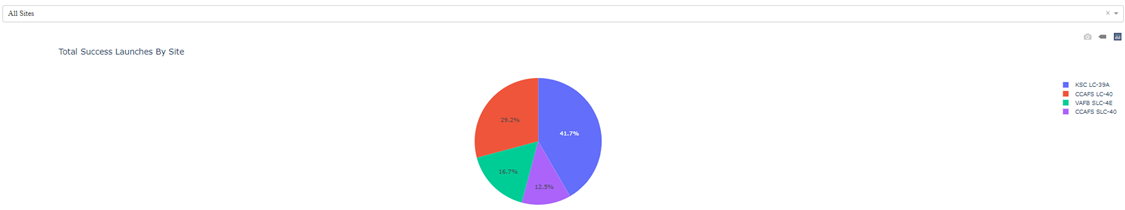

Gráfico de pastel para **is selected**:
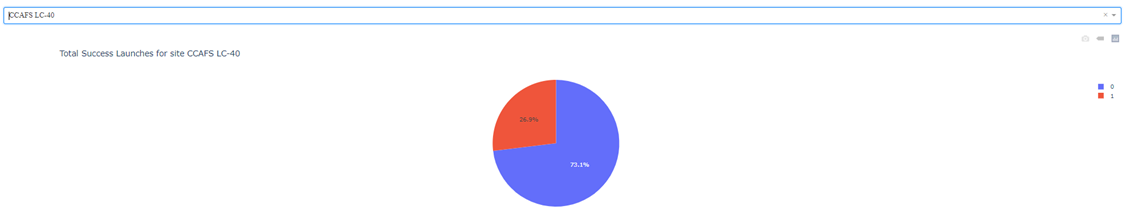
Si necesitas más referencias sobre dash callbacks y gráficos de pastel (pie charts) en Plotly, consulta la sec-ción Plotly Dash Reference hacia el final de este laboratorio.

In [7]:
# TASK 2:
# Add a callback function for `site-dropdown` as input, `success-pie-chart` as output
@app.callback(
    Output(component_id= 'success-pie-chart', component_property='figure'),
    Input(component_id='site-dropdown', component_property='value')
)
def update_pie_chart(selected_site):
    if selected_site == 'ALL':
        fig = px.pie(
            spacex_df,
            names = 'Launch Site',
            values = 'class',
            title ='Total Successful Launches for All Sites'
        )
    else:
        filtered_df = spacex_df[spacex_df['Launch Site'] == selected_site]
        fig = px.pie(
            filtered_df,
            names = 'class',
            title = f'Success vs Failure for site {selected_site}'
        )
    return fig

### Tarea 3. Agregar un control deslizante de rango para seleccionar el payload
A continuación, queremos averiguar si la variable payload está correlacionada con el resultado de la misión. Desde el punto de vista del dashboard, queremos poder seleccionar fácilmente diferentes rangos de payload y ver si podemos identificar algunos patrones visuales.
Encuentra y completa un componente comentado dcc.RangeSlider(id='payload-slider', ...) con el siguiente con-junto de atributos:
- **id** debe ser payload-slider
- **min** indica el punto inicial del control deslizante; establecemos su valor en 0 (Kg)
- **max** indica el punto final del control deslizante; establecemos su valor en 10000 (Kg)
- **step** indica el intervalo del control deslizante; establecemos su valor en 1000 (Kg)
- **value** indica el rango actualmente seleccionado; podemos establecerlo en min_payload y max_payload
Aquí tienes un ejemplo de un RangeSlider:
dcc.RangeSlider(id='id',
                min=0, max=10000, step=1000,
                marks={0: '0',
                       100: '100'},
                value=[min_value, max_value])
Tu control deslizante de rango para payload completado debería ser similar a la siguiente captura de pantalla:
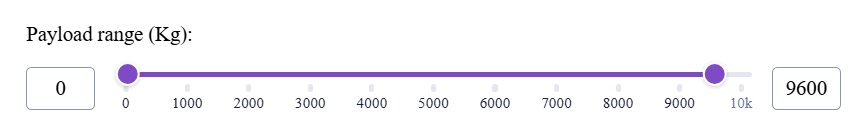

<strong><span style="color:red;">CODIGO</span></strong>

**VER EL CÓDIGO EN LA TAREA 1**

### Tarea 4. Agregar una función callback para reenderizar el gráfico de dispersión success-payload-scatter-chart
A continuación, queremos trazar un gráfico de dispersión donde el eje x sea el payload y el eje y sea el resultado del lanzamiento (es decir, la columna class). De esta manera, podemos observar visualmente cómo el payload podría estar correlacionado con los resultados de la misión para el(los) sitio(s) seleccionado(s).

Además, queremos asignar colores según la versión del Booster en cada punto del gráfico, de modo que poda-mos observar los resultados de misión con diferentes boosters.

Ahora, agreguemos una función callback que incluya la siguiente lógica de aplicación:

La entrada (Input) debe ser:
````
[Input(component_id='site-dropdown', component_property='value'), Input(component_id='payload-slider', component_property='value')]
````
Ten en cuenta que tenemos dos componentes de entrada:
uno para recibir el sitio de lanzamiento seleccionado y otro para recibir el rango de payload seleccionado.

La salida (Output) debe ser:
```` 
Output(component_id='success-payload-scatter-chart', component_property='figure')
````
Una sentencia If–Else para verificar si se seleccionaron TODOS los sitios o solo un sitio específico.

Si se seleccionan TODOS los sitios, se debe renderizar un gráfico de dispersión que muestre todos los valores de la variable Payload Mass (kg) y la variable class.
Además, el color de los puntos debe asignarse según la versión del booster, es decir:
````
color="Booster Version Category"
```` 

Si se selecciona un sitio específico, primero debes filtrar spacex_df y luego renderizar un gráfico de dispersión que muestre los valores de Payload Mass (kg) y class para ese sitio seleccionado, asignando también el color de los puntos según Booster Version Category.

Tu gráfico de dispersión renderizado debería verse como en la siguiente captura de pantalla:
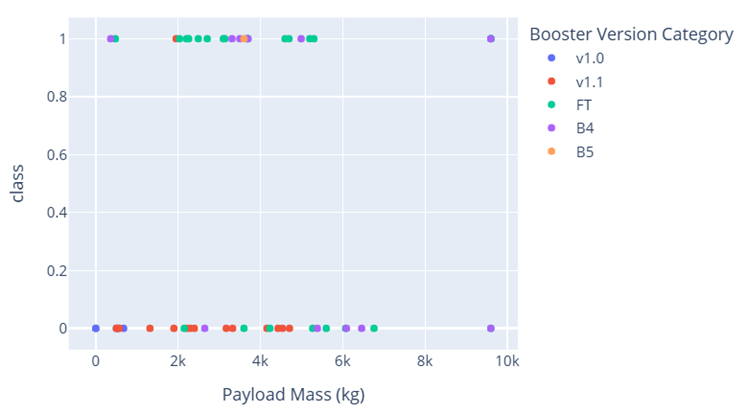

In [8]:
# TASK 4:
# Add a callback function for `site-dropdown` and `payload-slider` as inputs,
# `success-payload-scatter-chart` as output
@app.callback(
    Output(component_id='success-payload-scatter-chart', component_property='figure'),
    [
        Input(component_id='site-dropdown', component_property='value'),
        Input(component_id='payload-slider', component_property='value')
    ]
)
def update_scatter(selected_site, payload_range):
    low, high = payload_range
    df = spacex_df[(spacex_df['Payload Mass (kg)'] >= low) &
                   (spacex_df['Payload Mass (kg)'] <= high)]

    if selected_site != 'ALL':
        df = df[df['Launch Site'] == selected_site]

    fig = px.scatter(
        df,
        x='Payload Mass (kg)',
        y='class',
        color='Booster Version Category',
        title='Payload vs Launch Outcome'
    )
    return fig

In [9]:
# Run the app
if __name__ == '__main__':
    app.run()

- ¿Qué sitio tiene la mayor catidad de lanzamientos exitosos?
    KSC LC-39A con 41.7%
- ¿Qué sitio tiene la tasa de éxito de lanzamiento más alta?
    CCAFS SLC-40 con 42.9%
- ¿Qué rango(s) de payload tienen la tasa de éxito de lanzamiento más alta?
  El rango donde hubo más lanzamientos exitosos es de 2000 a 5000 Kg de carga útil donde lo más alto está de 3000 a 4000 con 7 lanzamientos con éxito
- ¿Qué rangos de payload tienen la tasa de éxito de lanzamiento más baja?
  De 6000 a 10000 tienen 1
- ¿Qué versión del F9 Booster(v1.0, v1.1, FT, B4, B5, etc) tiene la tasa de éxito de lanzamiento más alta
  FT es la versión del F9 Booster con la tasa de éxito de lanzamiento más alta: 13 lanzamientos